<a href="https://colab.research.google.com/github/andersonmoraix/analisedeconjuntura_anotacoes/blob/main/aula07_analisedeinflacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CURSO: Análise de Conjuntura usando Python - Análise Macro<br>
AULA: Análise de dados de inflação com Python<br>
INFORMAÇÕES: veja os principais conceitos no slides da aula<br>
AUTOR: Fernando da Silva/Cientista de dados

# Bibliotecas

In [ ]:
# Instala bibliotecas
!pip install sidrapy
!pip install python-bcb

# Importa bibliotecas
import sidrapy as sidra
import pandas as pd
from bcb import sgs

# IPCA e seus grupos

### Coleta de dados

In [ ]:
# Importa dados do IPCA (índice cheio e grupos, a partir de janeiro/2020)
# Variação mensal, acumulada em 12 meses e peso mensal
dados_brutos_ipca = list(
    map(
        # função que será repetida
        lambda variavel: (
            sidra.get_table(
                table_code = "7060",        # tabela mais recente
                territorial_level = "1",
                ibge_territorial_code = "1",
                variable = variavel,
                classifications = { # índice cheio e grupos
                    "315": "7169,7170,7445,7486,7558,7625,7660,7712,7766,7786"
                    },
                period = "all"
                )
            ),

        # códigos da variável dentro da tabela (pro argumento variavel)
        ["63", "2265", "66"]
        )
    )
dados_brutos_ipca

[                             NC                 NN  \
 0    Nível Territorial (Código)  Nível Territorial   
 1                             1             Brasil   
 2                             1             Brasil   
 3                             1             Brasil   
 4                             1             Brasil   
 ..                          ...                ...   
 326                           1             Brasil   
 327                           1             Brasil   
 328                           1             Brasil   
 329                           1             Brasil   
 330                           1             Brasil   
 
                              MC                 MN      V              D1C  \
 0    Unidade de Medida (Código)  Unidade de Medida  Valor  Brasil (Código)   
 1                             2                  %   0.21                1   
 2                             2                  %   0.39                1   
 3                    

### Tratamentos de dados

In [ ]:
# Tratamento de dados do IPCA
dados_ipca = (
    pd.concat(dados_brutos_ipca)
    .rename(columns = dados_brutos_ipca[0].iloc[0])
    .rename(
        columns = {
            "Mês (Código)": "data",
            "Valor": "valor",
            "Variável": "variavel",
            "Geral, grupo, subgrupo, item e subitem": "grupo"
            }
        )
    .query("valor not in ['Valor', '...']")
    .filter(items = ["data", "variavel", "grupo", "valor"], axis = "columns")
    .replace(
        to_replace = {
            "variavel": {
                "IPCA - Variação mensal": "Variação % mensal",
                "IPCA - Variação acumulada em 12 meses": "Variação % acum. 12 meses",
                "IPCA - Peso mensal": "Peso mensal"
                },
             "grupo": {"\d.": ""}
              },
        regex = True
        )
    .assign(
        data = lambda x: pd.to_datetime(x.data, format = "%Y%m"),
        valor = lambda x: x.valor.astype(float)
    )
)
dados_ipca

,data,variavel,grupo,valor
1,2020-01-01,Variação % mensal,Índice geral,0.2100
2,2020-01-01,Variação % mensal,Alimentação e bebidas,0.3900
3,2020-01-01,Variação % mensal,Habitação,0.5500
4,2020-01-01,Variação % mensal,Artigos de residência,-0.0700
5,2020-01-01,Variação % mensal,Vestuário,-0.4800
...,...,...,...,...
326,2022-09-01,Peso mensal,Transportes,20.7878
327,2022-09-01,Peso mensal,Saúde e cuidados pessoais,12.7941
328,2022-09-01,Peso mensal,Despesas pessoais,9.9651
329,2022-09-01,Peso mensal,Educação,5.6946


### Visualização de dados

[Text(0, 0, '01/20'),
 Text(0, 0, '02/20'),
 Text(0, 0, '03/20'),
 Text(0, 0, '04/20'),
 Text(0, 0, '05/20'),
 Text(0, 0, '06/20'),
 Text(0, 0, '07/20'),
 Text(0, 0, '08/20'),
 Text(0, 0, '09/20'),
 Text(0, 0, '10/20'),
 Text(0, 0, '11/20'),
 Text(0, 0, '12/20'),
 Text(0, 0, '01/21'),
 Text(0, 0, '02/21'),
 Text(0, 0, '03/21'),
 Text(0, 0, '04/21'),
 Text(0, 0, '05/21'),
 Text(0, 0, '06/21'),
 Text(0, 0, '07/21'),
 Text(0, 0, '08/21'),
 Text(0, 0, '09/21'),
 Text(0, 0, '10/21'),
 Text(0, 0, '11/21'),
 Text(0, 0, '12/21'),
 Text(0, 0, '01/22'),
 Text(0, 0, '02/22'),
 Text(0, 0, '03/22'),
 Text(0, 0, '04/22'),
 Text(0, 0, '05/22'),
 Text(0, 0, '06/22'),
 Text(0, 0, '07/22'),
 Text(0, 0, '08/22'),
 Text(0, 0, '09/22')]

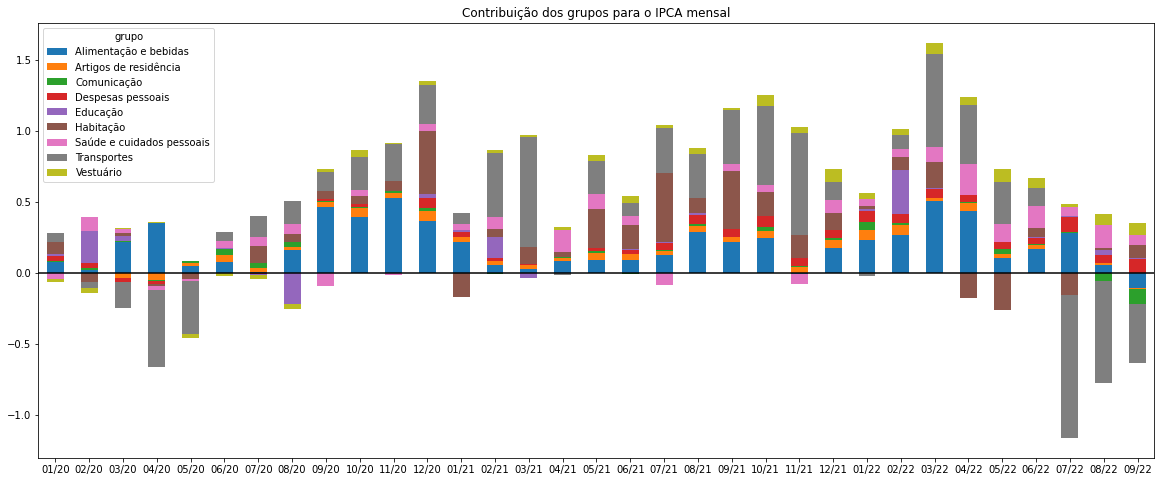

In [ ]:
# Gráfico de colunas empilhadas
# Contribuição dos grupos para o IPCA mensal (variação * peso / 100)
dados_contribuicao = (
    dados_ipca
    .query(
        "variavel in ['Variação % mensal', 'Peso mensal'] and grupo not in 'Índice geral'"
        )
    .pivot(index = ["data", "grupo"], columns = "variavel", values = "valor")
    .assign(
        contribuicao = lambda x: x["Variação % mensal"] * x["Peso mensal"] / 100
        )["contribuicao"]
    .unstack()
)

# Plota gráfico
(
   dados_contribuicao.plot(
        kind = "bar",
        stacked = True,
        figsize = (20,8),
        title = "Contribuição dos grupos para o IPCA mensal",
        xlabel = ""
        )
    .axhline(y = 0, color = "black")
    .axes.set_xticklabels(
        labels = [x.strftime("%m/%y") for x in dados_contribuicao.index],
        rotation = 0
        )
)


# Classificações do IPCA

### Coleta de dados

In [ ]:
# Importa dados das classificações do IPCA (BCB, % a.m.)
dados_brutos_classificações = sgs.get(
    codes = {
        "Livres": 11428,
        "Alimentação no domicílio": 27864,
        "Serviços": 10844,
        "Industriais": 27863,
        "Monitorados": 4449,
        "Comercializáveis": 4447,
        "Não comercializáveis": 4448
        },
    start = "2000-01-01"
)
dados_brutos_classificações

,Livres,Alimentação no domicílio,Serviços,Industriais,Monitorados,Comercializáveis,Não comercializáveis
Date,,,,,,,
2000-01-01,0.65,0.94,0.69,0.46,0.54,0.47,0.85
2000-02-01,0.22,-0.50,0.38,0.49,-0.15,0.10,0.37
2000-03-01,-0.11,-0.63,-0.11,0.16,1.22,-0.33,0.15
2000-04-01,0.54,-0.54,1.47,0.45,0.05,0.05,1.11
2000-05-01,-0.07,-0.98,-0.07,0.37,0.26,-0.04,-0.11
...,...,...,...,...,...,...,...
2022-05-01,0.83,0.43,0.85,1.06,-0.51,1.04,0.66
2022-06-01,0.74,0.63,0.90,0.58,0.48,0.50,0.93
2022-07-01,0.65,1.47,0.80,-0.11,-4.35,0.24,0.96


### Tratamento e visualização de dados

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f7aee548c90>,
      dtype=object)

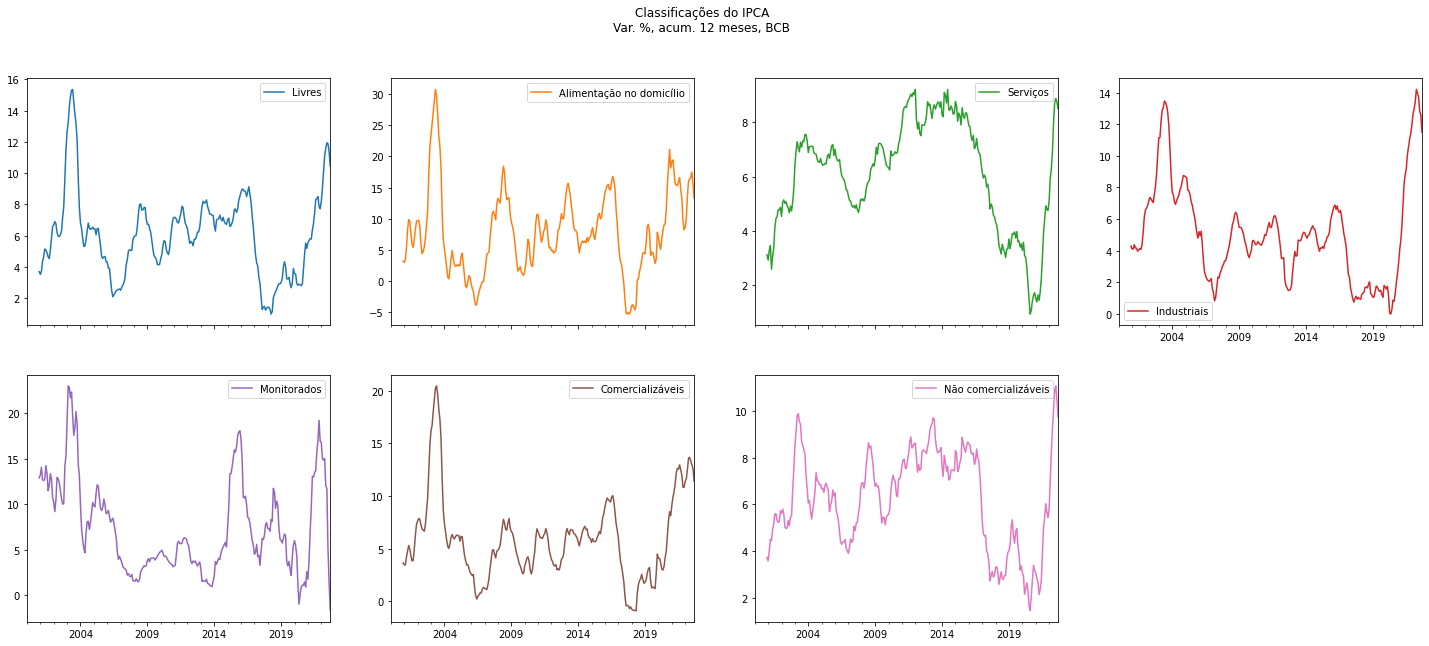

In [ ]:
# Acumula var. mensal em 12 períoros e gera gráfico de linha
(
    dados_brutos_classificações
    .rolling(window = 12)
    .apply(lambda x: ((x / 100 + 1).prod() - 1) * 100, raw = False)
    .plot(
        subplots = True,
        figsize = (25,10),
        layout = (2,4),
        title = "Classificações do IPCA\nVar. %, acum. 12 meses, BCB",
        xlabel = ""
        )
)

# Índice de Difusão

### Coleta e visualização de dados

In [ ]:
# Importa dados do índice no SGS/BCB
dados_brutos_difusao = sgs.get(codes = {"Índice de Difusão": 21379}, start = "2000-01-01")
dados_brutos_difusao

,Índice de Difusão
Date,
2000-01-01,68.75
2000-02-01,53.52
2000-03-01,51.17
2000-04-01,56.84
2000-05-01,51.76
...,...
2022-05-01,72.41
2022-06-01,66.58
2022-07-01,62.86


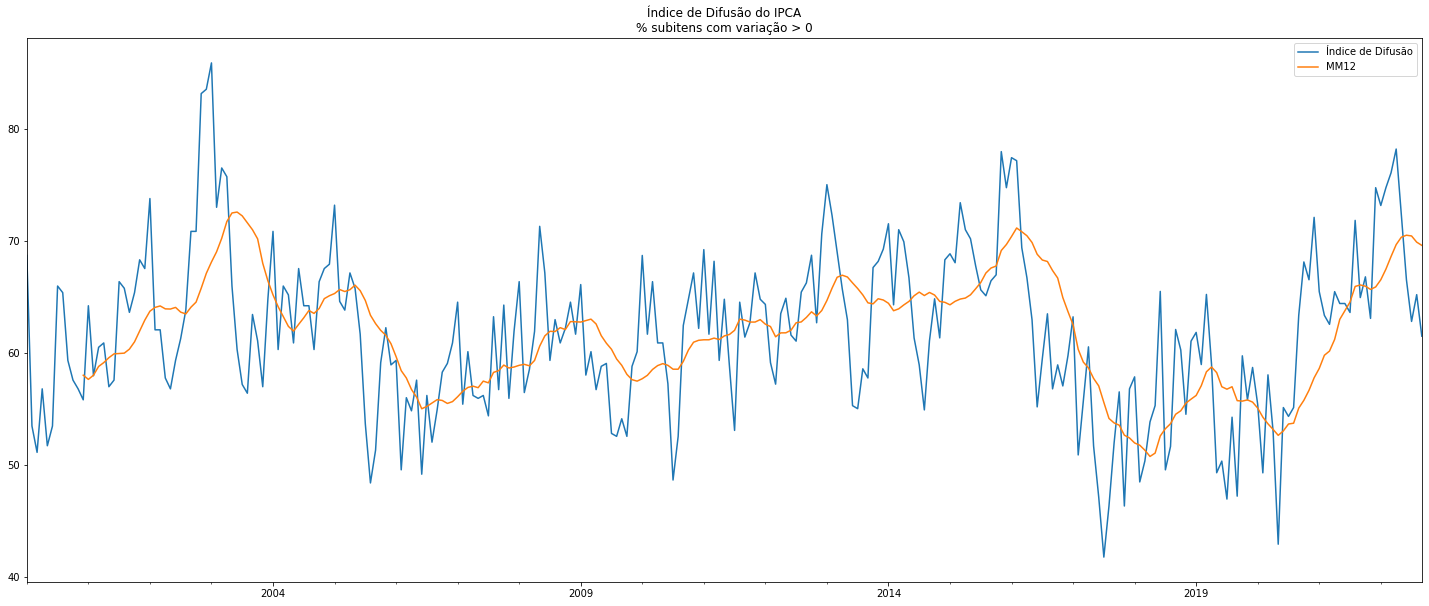

In [ ]:
# Gera gráfico de linha do índice e sua média móvel
(
    dados_brutos_difusao
    .assign(MM12 = lambda x: x.rolling(12).mean())
    .plot(
    figsize = (25,10),
    title = "Índice de Difusão do IPCA\n% subitens com variação > 0",
    xlabel = ""
    )
)

# Núcleos de inflação

### Coleta de dados

In [ ]:
# Importa dados dos 7 núcleos de inflação
dados_brutos_nucleos = sgs.get(
    codes = {
        "IPCA-EX0": 11427,
        "IPCA-EX1": 16121,
        "IPCA-EX2": 27838,
        "IPCA-EX3": 27839,
        "IPCA-MA": 11426,
        "IPCA-MS": 4466,
        "IPCA-DP": 16122
        },
    start = "2000-01-01"
)
dados_brutos_nucleos

,IPCA-EX0,IPCA-EX1,IPCA-EX2,IPCA-EX3,IPCA-MA,IPCA-MS,IPCA-DP
Date,,,,,,,
2000-01-01,0.56,0.63,0.42,0.33,NaN,0.48,0.47
2000-02-01,0.45,0.32,0.17,0.21,NaN,0.44,0.32
2000-03-01,0.05,0.16,-0.11,-0.03,NaN,0.37,0.21
2000-04-01,0.87,0.62,0.16,0.22,NaN,0.45,0.60
2000-05-01,0.20,0.19,0.12,0.16,NaN,0.35,0.18
...,...,...,...,...,...,...,...
2022-05-01,0.94,0.52,1.10,1.06,0.89,0.98,0.86
2022-06-01,0.77,0.90,0.98,1.01,0.71,0.97,0.93
2022-07-01,0.43,0.36,0.67,0.63,0.49,0.62,0.41


### Visualização de dados

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f7aedf7e550>,
      dtype=object)

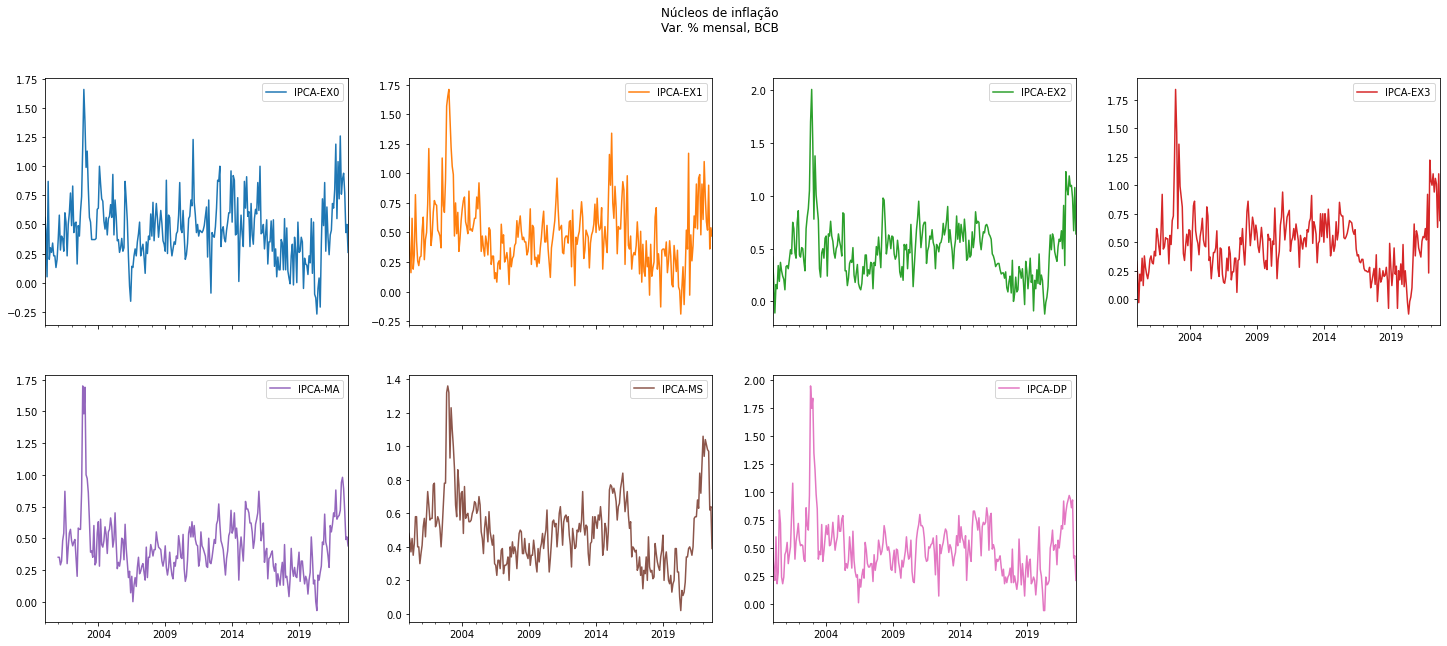

In [ ]:
# Gera gráfico de linha
dados_brutos_nucleos.plot(
    subplots = True,
    figsize = (25,10),
    layout = (2,4),
    title = "Núcleos de inflação\nVar. % mensal, BCB",
    xlabel = ""
    )